<a href="https://colab.research.google.com/github/myriosMin/SP500-News-Sentiment-Analysis/blob/main/HDI_Salary_Analysis%5BAlex%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [ ]:
#this cell may take a while
import requests
!pip install opendatasets
import opendatasets as od
!pip install yfinance
import yfinance as yf

# HDI - Alex

Human Development Index is a combined metric per capita of life expectancy, education and income of a nation.
This dataset is used to identify the top countries with the most potential market for investment firms like Black Guard.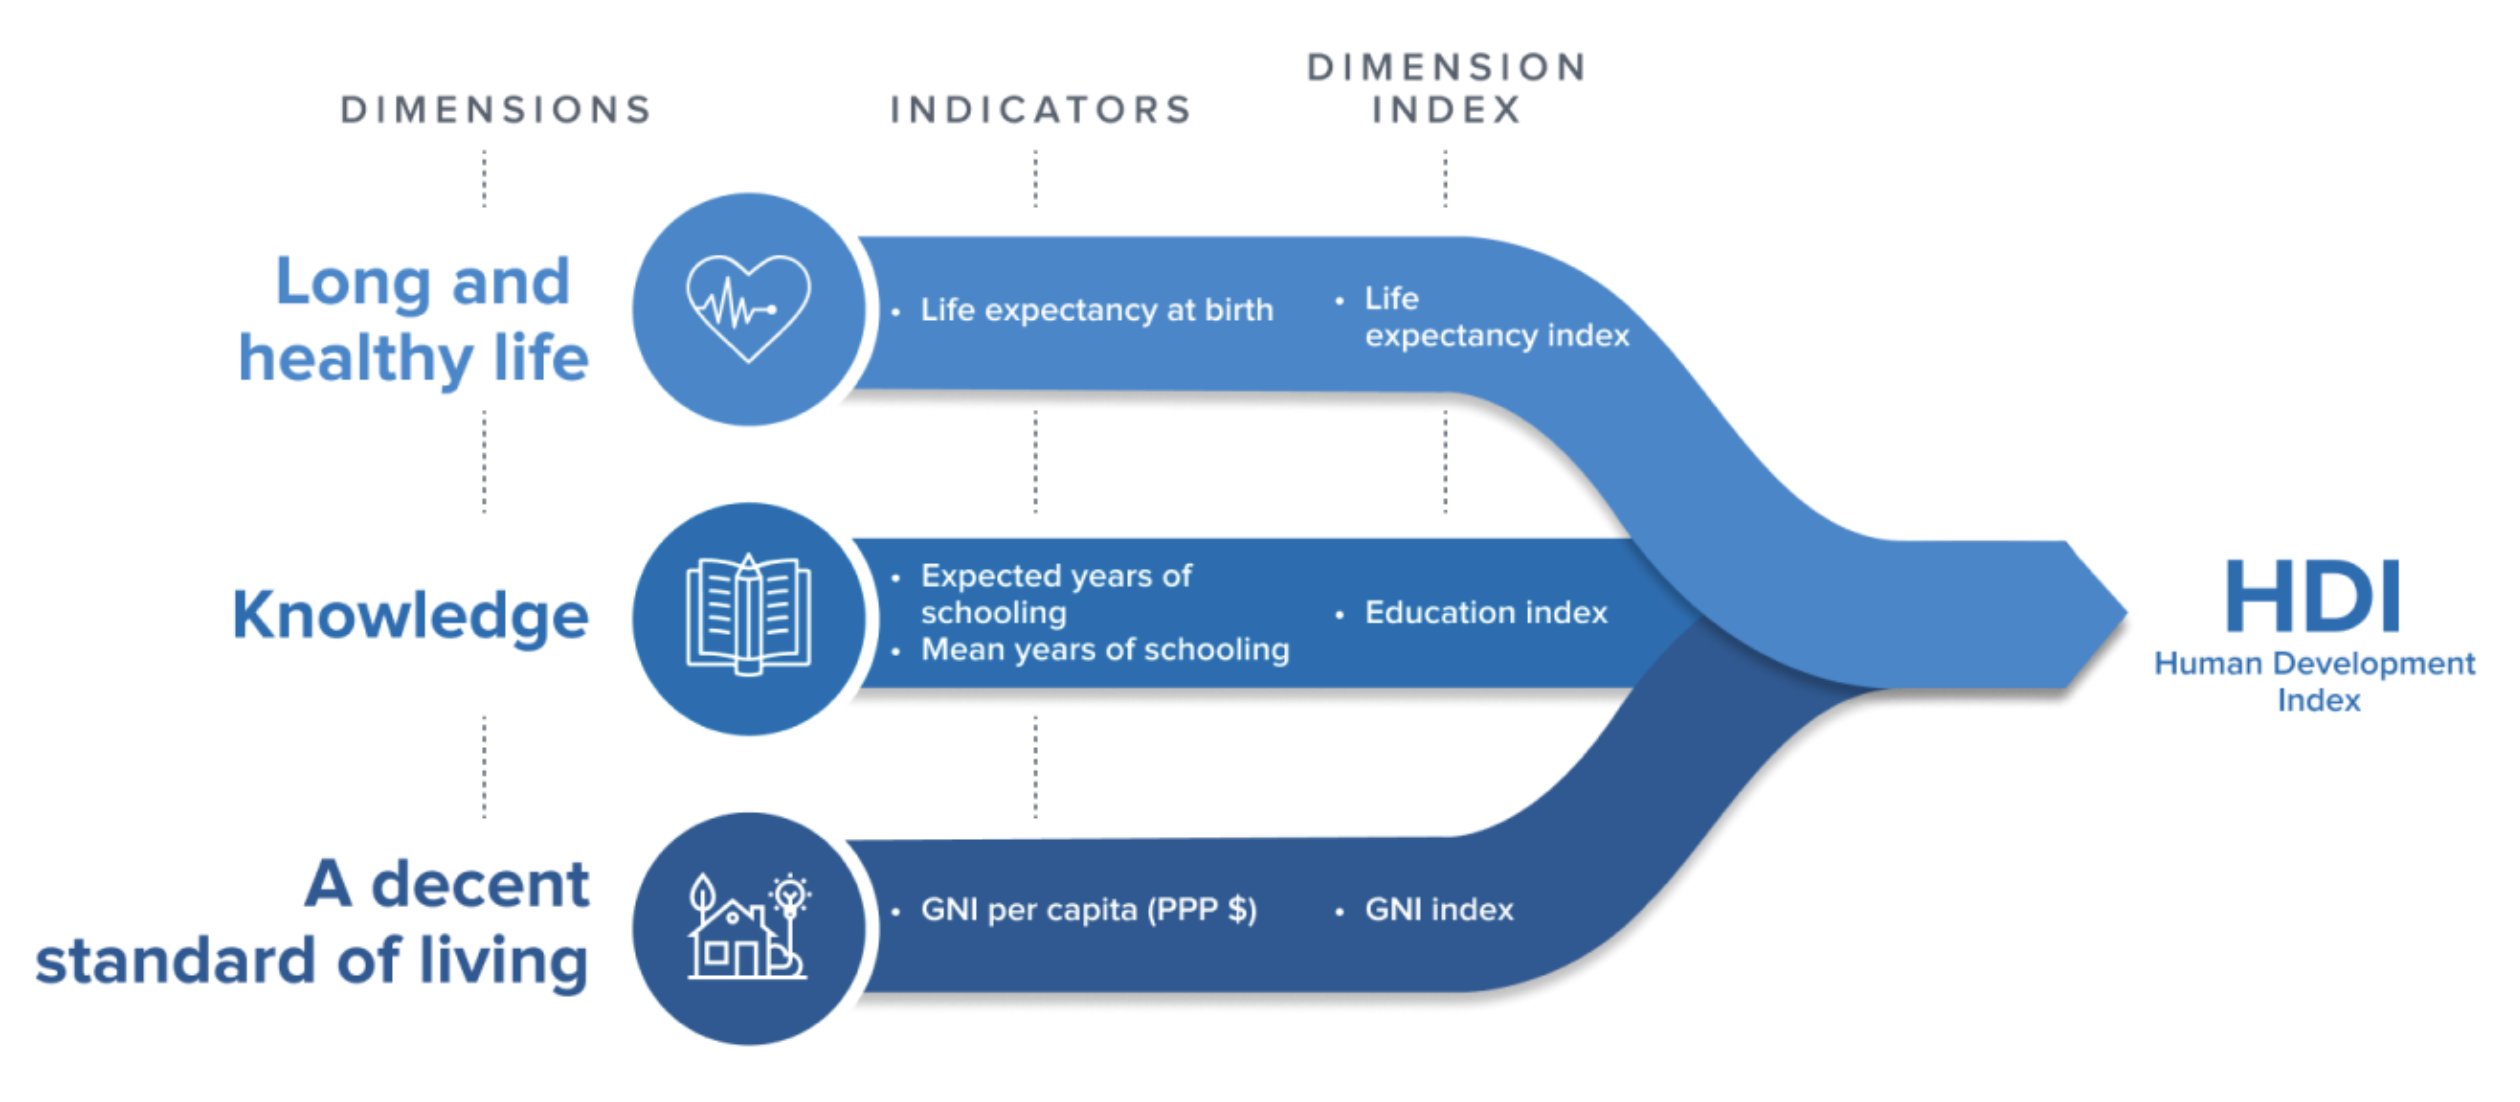

In [ ]:
url = "https://hdr.undp.org/sites/default/files/2023-24_HDR/HDR23-24_Composite_indices_complete_time_series.csv"

response = requests.get(url)

with open('hdi_raw.csv', 'wb') as file:
    file.write(response.content)

hdi = pd.read_csv('hdi_raw.csv', encoding='latin-1')

hdi.head().T

,0,1,2,3,4
iso3,AFG,ALB,DZA,AND,AGO
country,Afghanistan,Albania,Algeria,Andorra,Angola
hdicode,Low,High,High,Very High,Medium
region,SA,ECA,AS,NaN,SSA
hdi_rank_2022,182.0,74.0,93.0,35.0,150.0
...,...,...,...,...,...
pop_total_2018,36.686784,2.877013,41.927007,0.075013,31.273533
pop_total_2019,37.769498,2.873883,42.705368,0.076343,32.353588
pop_total_2020,38.972231,2.866849,43.451666,0.0777,33.428486
pop_total_2021,40.099462,2.85471,44.177968,0.079034,34.503774


In [ ]:
hdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Columns: 1076 entries, iso3 to pop_total_2022
dtypes: float64(1072), object(4)
memory usage: 1.7+ MB


In [ ]:
hdi.isnull().sum()

,0
iso3,0
country,0
hdicode,13
region,55
hdi_rank_2022,13
...,...
pop_total_2018,0
pop_total_2019,0
pop_total_2020,0
pop_total_2021,0


In [ ]:
Nhdi = hdi[['iso3', 'country', 'hdicode', 'region', 'hdi_rank_2022',
           'hdi_1990', 'hdi_1991', 'hdi_1992', 'hdi_1993', 'hdi_1994',
           'hdi_1995', 'hdi_1996', 'hdi_1997', 'hdi_1998', 'hdi_1999',
           'hdi_2000', 'hdi_2001', 'hdi_2002', 'hdi_2003', 'hdi_2004',
           'hdi_2005', 'hdi_2006', 'hdi_2007', 'hdi_2008', 'hdi_2009',
           'hdi_2010', 'hdi_2011', 'hdi_2012', 'hdi_2013', 'hdi_2014',
           'hdi_2015', 'hdi_2016', 'hdi_2017', 'hdi_2018', 'hdi_2019',
           'hdi_2020', 'hdi_2021', 'hdi_2022']]


In [ ]:
Nhdi.columns

Index(['iso3', 'country', 'hdicode', 'region', 'hdi_rank_2022', 'hdi_1990',
       'hdi_1991', 'hdi_1992', 'hdi_1993', 'hdi_1994', 'hdi_1995', 'hdi_1996',
       'hdi_1997', 'hdi_1998', 'hdi_1999', 'hdi_2000', 'hdi_2001', 'hdi_2002',
       'hdi_2003', 'hdi_2004', 'hdi_2005', 'hdi_2006', 'hdi_2007', 'hdi_2008',
       'hdi_2009', 'hdi_2010', 'hdi_2011', 'hdi_2012', 'hdi_2013', 'hdi_2014',
       'hdi_2015', 'hdi_2016', 'hdi_2017', 'hdi_2018', 'hdi_2019', 'hdi_2020',
       'hdi_2021', 'hdi_2022'],
      dtype='object')

In [ ]:
# FIND HDI DATA FROM PAST 5 YEARS STARTING 2022
hdi_recent = Nhdi[['country', 'hdi_2018', 'hdi_2019', 'hdi_2020', 'hdi_2021', 'hdi_2022']]
hdi_recent['avg_hdi_5yrs'] = hdi_recent[['hdi_2018', 'hdi_2019', 'hdi_2020', 'hdi_2021', 'hdi_2022']].mean(axis=1)
top_50 = hdi_recent.sort_values('avg_hdi_5yrs', ascending=False).head(50)

print(top_50)

                         country  hdi_2018  hdi_2019  hdi_2020  hdi_2021  \
130                       Norway     0.960     0.961     0.963     0.964   
169                  Switzerland     0.957     0.960     0.957     0.965   
76                       Iceland     0.958     0.958     0.955     0.957   
74        Hong Kong, China (SAR)     0.949     0.953     0.955     0.959   
64                       Germany     0.946     0.951     0.948     0.948   
168                       Sweden     0.943     0.947     0.944     0.949   
46                       Denmark     0.942     0.946     0.946     0.947   
8                      Australia     0.941     0.941     0.948     0.949   
81                       Ireland     0.938     0.942     0.945     0.946   
157                    Singapore     0.942     0.945     0.942     0.942   
124                  Netherlands     0.939     0.941     0.938     0.941   
59                       Finland     0.936     0.939     0.939     0.941   
125         

<ipython-input-8-925e21995297>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_recent['avg_hdi_5yrs'] = hdi_recent[['hdi_2018', 'hdi_2019', 'hdi_2020', 'hdi_2021', 'hdi_2022']].mean(axis=1)


In [ ]:
# CALCULATE MEAN HDI FOR EACH COUNTRY THEN SORT BY HIGHEST AVERAGE HDI
columns_of_interest = ['country', 'hdi_2022', 'hdi_2021', 'hdi_2020', 'hdi_2019', 'hdi_2018']

hdi_recent_years = hdi[columns_of_interest]

hdi_recent_years['average_hdi'] = hdi_recent_years[['hdi_2022', 'hdi_2021', 'hdi_2020', 'hdi_2019', 'hdi_2018']].mean(axis=1)

hdi_sorted = hdi_recent_years.sort_values(by='average_hdi', ascending=False)

top_50_countries = hdi_sorted.head(50)

top_50_countries

<ipython-input-9-0e07e753c818>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdi_recent_years['average_hdi'] = hdi_recent_years[['hdi_2022', 'hdi_2021', 'hdi_2020', 'hdi_2019', 'hdi_2018']].mean(axis=1)


,country,hdi_2022,hdi_2021,hdi_2020,hdi_2019,hdi_2018,average_hdi
130,Norway,0.966,0.964,0.963,0.961,0.960,0.9628
169,Switzerland,0.967,0.965,0.957,0.960,0.957,0.9612
76,Iceland,0.959,0.957,0.955,0.958,0.958,0.9574
74,"Hong Kong, China (SAR)",0.956,0.959,0.955,0.953,0.949,0.9544
64,Germany,0.950,0.948,0.948,0.951,0.946,0.9486
168,Sweden,0.952,0.949,0.944,0.947,0.943,0.9470
46,Denmark,0.952,0.947,0.946,0.946,0.942,0.9466
8,Australia,0.946,0.949,0.948,0.941,0.941,0.9450
81,Ireland,0.950,0.946,0.945,0.942,0.938,0.9442
157,Singapore,0.949,0.942,0.942,0.945,0.942,0.9440


In [ ]:
# SHOW ALL UNIQUE VALUES IN THE TOP 50 COUNTRIES

unique_countries = top_50_countries['country'].unique()
print(unique_countries)


['Norway' 'Switzerland' 'Iceland' 'Hong Kong, China (SAR)' 'Germany'
 'Sweden' 'Denmark' 'Australia' 'Ireland' 'Singapore' 'Netherlands'
 'Finland' 'New Zealand' 'Belgium' 'Liechtenstein' 'Canada'
 'United Kingdom' 'United Arab Emirates' 'United States' 'Luxembourg'
 'Korea (Republic of)' 'Austria' 'Japan' 'Slovenia' 'Israel' 'Malta'
 'France' 'Spain' 'Cyprus' 'Very high human development' 'Italy' 'Czechia'
 'Estonia' 'Greece' 'Bahrain' 'Lithuania' 'Poland' 'Latvia' 'Qatar'
 'Croatia' 'Portugal' 'Saudi Arabia' 'Andorra' 'Slovakia' 'San Marino'
 'Chile' 'Hungary' 'Argentina' 'Türkiye' 'Montenegro']


In [ ]:
# COLLECT LIFE EXPECTANCY DATA FROM 2018-2022 FOR TOP 50 COUNTRIES

# Create an empty list to store the data for the new DataFrame
data = []

# Iterate through the unique countries
for country in unique_countries:
  for year in range(2018, 2023):  # Years 2018 to 2022
    # Extract the HDI value for the country and year
    le_value = hdi.loc[hdi['country'] == country, f'le_{year}'].values[0]

    # Append the data to the list
    data.append([country, year, le_value])

# Create the new DataFrame
top_50_countries_le = pd.DataFrame(data, columns=['country', 'le_year', 'le'])

# Display the new DataFrame
print(top_50_countries_le)


        country  le_year      le
0        Norway     2018  82.760
1        Norway     2019  82.955
2        Norway     2020  83.195
3        Norway     2021  83.234
4        Norway     2022  83.393
..          ...      ...     ...
245  Montenegro     2018  77.159
246  Montenegro     2019  77.040
247  Montenegro     2020  76.257
248  Montenegro     2021  76.343
249  Montenegro     2022  76.845

[250 rows x 3 columns]


In [ ]:
# COLLECT SCHOOLING DATA FROM 2018-2022 FOR TOP 50 COUNTRIES

# Create an empty list to store the data for the new DataFrame
data = []

# Iterate through the unique countries
for country in unique_countries:
  for year in range(2018, 2023):  # Years 2018 to 2022
    # Extract the HDI value for the country and year
    mys_value = hdi.loc[hdi['country'] == country, f'mys_{year}'].values[0]

    # Append the data to the list
    data.append([country, year, mys_value])

# Create the new DataFrame
top_50_countries_mys = pd.DataFrame(data, columns=['country', 'mys_year', 'mys'])

# Display the new DataFrame
print(top_50_countries_mys)

        country  mys_year        mys
0        Norway      2018  12.975395
1        Norway      2019  13.003630
2        Norway      2020  13.062343
3        Norway      2021  13.062343
4        Norway      2022  13.062343
..          ...       ...        ...
245  Montenegro      2018  12.310160
246  Montenegro      2019  12.462247
247  Montenegro      2020  12.616213
248  Montenegro      2021  12.616213
249  Montenegro      2022  12.616213

[250 rows x 3 columns]


In [ ]:
# COLLECT NATIONAL INCOME DATA FROM 2018-2022 FOR TOP 50 COUNTRIES

# Create an empty list to store the data for the new DataFrame
data = []

# Iterate through the unique countries
for country in unique_countries:
  for year in range(2018, 2023):  # Years 2018 to 2022
    # Extract the HDI value for the country and year
    gnipc_value = hdi.loc[hdi['country'] == country, f'gnipc_{year}'].values[0]

    # Append the data to the list
    data.append([country, year, gnipc_value])

# Create the new DataFrame
top_50_countries_gnipc = pd.DataFrame(data, columns=['country', 'gnipc_year', 'gnipc'])

# Display the new DataFrame
print(top_50_countries_gnipc)

        country  gnipc_year        gnipc
0        Norway        2018  67394.01179
1        Norway        2019  66977.37410
2        Norway        2020  66258.16613
3        Norway        2021  67596.61386
4        Norway        2022  69189.76165
..          ...         ...          ...
245  Montenegro        2018  20923.54288
246  Montenegro        2019  21767.12591
247  Montenegro        2020  18548.47848
248  Montenegro        2021  21142.48906
249  Montenegro        2022  22513.26314

[250 rows x 3 columns]


In [ ]:
# top_50_countries.to_csv('top_50_countries_hdi.csv', index=False)
# top_50_countries_le.to_csv('top_50_countries_le.csv', index=False)
# top_50_countries_mys.to_csv('top_50_countries_mys.csv', index=False)
# top_50_countries_gnipc.to_csv('top_50_countries_gnipc.csv', index=False)


# Median Salary by Country - Alex

The median salary by country is used to find the appropriate amount of income to be invested per month

In [ ]:
od.download("https://www.kaggle.com/datasets/zedataweaver/global-salary-data")
#myrios
#myriosmy
#DO NOT SHARE THE API KEY WITH OTHERS

#download the dataset from Kaggle
od.download("https://www.kaggle.com/datasets/myrios/cost-of-living-index-by-country-by-number-2024")
#API username and KEY
#myrios
#Kaggle api key
#DO NOT SHARE THE API KEY WITH OTHERS

od.download("https://www.kaggle.com/datasets/amirmahdiabbootalebi/salary-by-job-title-and-country")
#myrios
#Kaggle api key
#DO NOT SHARE THE API KEY WITH OTHERS

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/zedataweaver/global-salary-data


100%|██████████| 5.42k/5.42k [00:00<00:00, 7.50MB/s]


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

 myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/myrios/cost-of-living-index-by-country-by-number-2024


100%|██████████| 2.83k/2.83k [00:00<00:00, 4.77MB/s]


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

 myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/amirmahdiabbootalebi/salary-by-job-title-and-country


100%|██████████| 86.5k/86.5k [00:00<00:00, 16.1MB/s]

In [ ]:
salary = pd.read_csv('/content/global-salary-data/salary_data.csv')
coli = pd.read_csv('/content/cost-of-living-index-by-country-by-number-2024/Cost_of_Living_Index_by_Country_2024.csv', index_col="Rank")
salary.head()

,country_name,continent_name,wage_span,median_salary,average_salary,lowest_salary,highest_salary
0,Afghanistan,Asia,Monthly,853.74,1001.15,252.53,4460.97
1,Aland Islands,Europe,Monthly,3319.24,3858.35,972.52,17124.74
2,Albania,Europe,Monthly,832.84,956.92,241.22,4258.49
3,Algeria,Africa,Monthly,1148.84,1308.81,330.11,5824.18
4,American Samoa,Oceania,Monthly,1390.00,1570.00,400.00,6980.00


In [ ]:
coli.head()

,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
Rank,,,,,,,
1,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
2,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
3,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
4,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
5,Barbados,76.6,19.0,48.9,80.8,69.4,43.5


In [ ]:
# GET ALL RELEVANT COLUMNS FOR ANALYSIS
salary = salary[['country_name', 'median_salary']]
salary.head()

,country_name,median_salary
0,Afghanistan,853.74
1,Aland Islands,3319.24
2,Albania,832.84
3,Algeria,1148.84
4,American Samoa,1390.00


In [ ]:
# GET ALL RELEVANT COLUMNS FOR ANALYSIS
coli = coli[['Country', 'Cost of Living Index']]
coli.head()

,Country,Cost of Living Index
Rank,,
1,Switzerland,101.1
2,Bahamas,85.0
3,Iceland,83.0
4,Singapore,76.7
5,Barbados,76.6


# Cost of Living - Alex

The cost of living for all countries is used to identify the suitable amount to be investment per month. This can be done by substracting the living cost from monthly salary.

In [ ]:
coli.head()

,Country,Cost of Living Index
Rank,,
1,Switzerland,101.1
2,Bahamas,85.0
3,Iceland,83.0
4,Singapore,76.7
5,Barbados,76.6


In [ ]:
# CALCULATE ALL INDEX VALUES TO MONETARY VALUES, INDEX 100 = 1640.90 USD
index_value_100 = 1640.90
coli['Actual Dollar Value'] = (coli['Cost of Living Index'] / 100) * index_value_100

<ipython-input-21-a6c98d905ac6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coli['Actual Dollar Value'] = (coli['Cost of Living Index'] / 100) * index_value_100


In [ ]:
coli.head()

,Country,Cost of Living Index,Actual Dollar Value
Rank,,,
1,Switzerland,101.1,1658.9499
2,Bahamas,85.0,1394.7650
3,Iceland,83.0,1361.9470
4,Singapore,76.7,1258.5703
5,Barbados,76.6,1256.9294


In [ ]:
coli['Actual Dollar Value'] = coli['Actual Dollar Value'].round(2)
coli.head()

<ipython-input-23-3cff9e68c972>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coli['Actual Dollar Value'] = coli['Actual Dollar Value'].round(2)


,Country,Cost of Living Index,Actual Dollar Value
Rank,,,
1,Switzerland,101.1,1658.95
2,Bahamas,85.0,1394.76
3,Iceland,83.0,1361.95
4,Singapore,76.7,1258.57
5,Barbados,76.6,1256.93


In [ ]:
# CROSS REFERENCE SALARY DATA WITH COLI DATA

# Find common countries
common_countries = set(coli['Country']).intersection(set(salary['country_name']))

# Filter dataframes
coli_filtered = coli[coli['Country'].isin(common_countries)]
salary_filtered = salary[salary['country_name'].isin(common_countries)]

# Merge dataframes
COLandMedianSal = pd.merge(coli_filtered, salary_filtered, left_on='Country', right_on='country_name')

COLandMedianSal = COLandMedianSal.drop('country_name', axis=1)
# Print the merged dataset
COLandMedianSal.head()


,Country,Cost of Living Index,Actual Dollar Value,median_salary
0,Switzerland,101.1,1658.95,9836.07
1,Bahamas,85.0,1394.76,3541.00
2,Iceland,83.0,1361.95,4661.20
3,Singapore,76.7,1258.57,5647.06
4,Barbados,76.6,1256.93,1395.00


In [ ]:
COLandMedianSal.shape

(113, 4)

In [ ]:
# CALCULATE DISPOSABLE INCOME FOR INDIVIDUALS FOR EACH COUNTRY
COLandMedianSal['Remaining amount'] = COLandMedianSal['median_salary'] - COLandMedianSal['Actual Dollar Value']

In [ ]:
COLandMedianSal.head()

,Country,Cost of Living Index,Actual Dollar Value,median_salary,Remaining amount
0,Switzerland,101.1,1658.95,9836.07,8177.12
1,Bahamas,85.0,1394.76,3541.00,2146.24
2,Iceland,83.0,1361.95,4661.20,3299.25
3,Singapore,76.7,1258.57,5647.06,4388.49
4,Barbados,76.6,1256.93,1395.00,138.07


In [ ]:
# REMOVE ALL COUNTRIES WITH NO DISPOSABLE INCOME
COLandMedianSal = COLandMedianSal[COLandMedianSal['Remaining amount'] >= 0]


In [ ]:
COLandMedianSal['Investable amount'] = (COLandMedianSal['Remaining amount'] * 0.25).round(2)
COLandMedianSal.head()

,Country,Cost of Living Index,Actual Dollar Value,median_salary,Remaining amount,Investable amount
0,Switzerland,101.1,1658.95,9836.07,8177.12,2044.28
1,Bahamas,85.0,1394.76,3541.00,2146.24,536.56
2,Iceland,83.0,1361.95,4661.20,3299.25,824.81
3,Singapore,76.7,1258.57,5647.06,4388.49,1097.12
4,Barbados,76.6,1256.93,1395.00,138.07,34.52


In [ ]:
# COLandMedianSal.to_csv("investable_amount_by_country.csv")

In [ ]:
# CROSS REFER DATASET TO HDI AND FILTER OUT COUNTRIES IN TOP 50 HDI

# Get the list of top 50 countries by average HDI
top_50_country_list = top_50_countries['country'].tolist()

# Filter COLandMedianSal to include only those countries
COLandMedianSal_top50 = COLandMedianSal[COLandMedianSal['Country'].isin(top_50_country_list)]

# Print the filtered dataset
print(COLandMedianSal_top50)


                 Country  Cost of Living Index  Actual Dollar Value  \
0            Switzerland                 101.1              1658.95   
2                Iceland                  83.0              1361.95   
3              Singapore                  76.7              1258.57   
5                 Norway                  76.0              1247.08   
6                Denmark                  72.3              1186.37   
7          United States                  70.4              1155.19   
8              Australia                  70.2              1151.91   
9                Austria                  65.1              1068.23   
10                Canada                  64.8              1063.30   
11           New Zealand                  64.6              1060.02   
12               Ireland                  64.4              1056.74   
13                France                  63.7              1045.25   
15               Finland                  63.2              1037.05   
16    

In [ ]:
COLandMedianSal_top50.to_csv("investable_amount_by_country_top50.csv")

# Income Vs Job Roles - Alex

The job roles by income dataset is used to identify the target customers who have high income jobs.

In [ ]:
income = pd.read_csv('/content/salary-by-job-title-and-country/Salary.csv')
income.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32.0,Male,1,Software Engineer,5.0,90000.0,UK,White,0
1,28.0,Female,2,Data Analyst,3.0,65000.0,USA,Hispanic,0
2,45.0,Male,3,Manager,15.0,150000.0,Canada,White,1
3,36.0,Female,1,Sales Associate,7.0,60000.0,USA,Hispanic,0
4,52.0,Male,2,Director,20.0,200000.0,USA,Asian,0
